In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils import * 

# Load feature tables 

In [64]:
from pathlib import Path
import pandas as pd
import numpy as np

base = Path("clean_tables")
PRIMARY_KEY = "RowKey"

# 1. Load feature tables
sql_df    = pd.read_csv(base / "sql_metrics.csv")
static_df = pd.read_csv(base / "static_metrics.csv")
dynamic_df= pd.read_csv(base / "dynamic_metrics.csv")
graph_df = pd.read_csv(base / "graph_metrics.csv")
qiskit_df  = pd.read_csv(base / "qiskit_simulation.csv")
rdbms_df  = pd.read_csv(base / "rdbms_simulation.csv")

# 2. Merge feature tables first (numeric features)
feature_df = sql_df # Only use SQL features for RDBMS analysis

# feature_df = sql_df.merge(static_df, on=PRIMARY_KEY, how="outer") \
#                        .merge(dynamic_df, on=PRIMARY_KEY, how="outer") \
#                        .merge(graph_df, on=PRIMARY_KEY, how="outer") \
# 3. FEATURES = numeric columns only (excluding PRIMARY_KEY)

FEATURES = feature_df.select_dtypes(include=[np.number]).columns.tolist()

# 4. Keep only memory_usage / execution_time columns
keep_suffixes = ["mb", "time_s"]
rdbms_cols = [PRIMARY_KEY] + [c for c in rdbms_df.columns if any(c.endswith(s) for s in keep_suffixes)]
rdbms_df = rdbms_df[rdbms_cols]

# 5. Merge feature_df with RDBMS columns to get final ML-ready df
df = feature_df.merge(rdbms_df, on=PRIMARY_KEY)
# Drop columns with nan in FEATURES
# Print initial number of rows
# Rows with all FEATURES present
df_feat_ok = df.dropna(subset=FEATURES, how="any")

sim_cols = [c for c in rdbms_df.columns if c != PRIMARY_KEY and 'sqlite' in c]

df_valid = df_feat_ok[df_feat_ok[sim_cols].notna().any(axis=1)]
df_all   = df_feat_ok.dropna(subset=sim_cols, how="any")

print("Rows with all FEATURES valid and ≥1 sim non-PK column non-NaN:", len(df_valid))
print("Rows with all FEATURES valid and ALL sim non-PK columns non-NaN:", len(df_all))
df = df_all

# Mean the von neumann entropy which is current a list per row
# df['vn_entropy'] = df['statevector_saved_von_neumann_entropy'].apply(lambda x: np.mean(eval(x)) if pd.notna(x) else np.nan)

C:\Users\aadik\AppData\Local\Temp\ipykernel_22156\369871576.py:13: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  qiskit_df  = pd.read_csv(base / "qiskit_simulation.csv")


Rows with all FEATURES valid and ≥1 sim non-PK column non-NaN: 8827
Rows with all FEATURES valid and ALL sim non-PK columns non-NaN: 8827


# Generated query (Tim's code) has highly correlated features

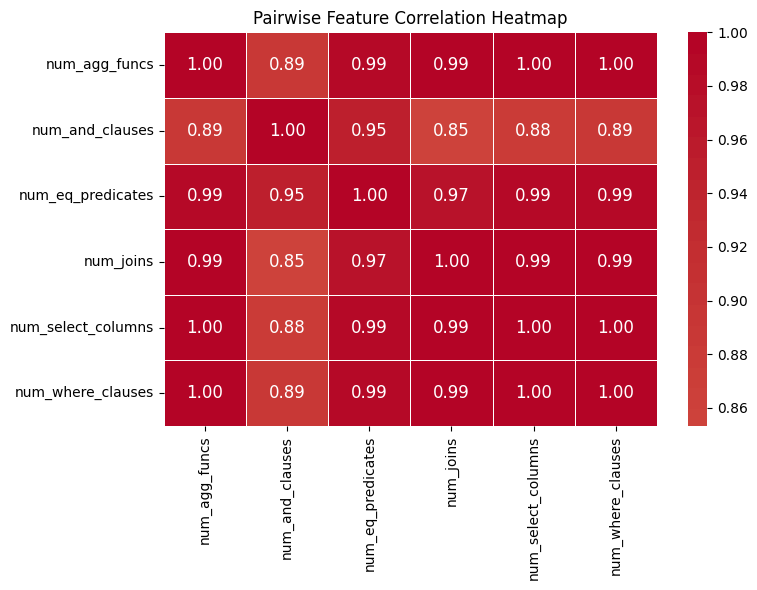

num_and_clauses       123
num_joins             156
num_agg_funcs         204
num_where_clauses     205
num_select_columns    207
num_eq_predicates     315
dtype: int64

In [65]:
# Plot the correlation matrix using utils.PlotCorrelationMatrix
from utils import PlotCorrelationMatrix
DROP_COLS = [
    "num_subqueries_with",
    "num_order_bys",
    "num_group_bys",
    "num_unique_join_edges",
    "num_join_occurrences",
    # "num_select_columns",
    # "num_where_clauses",
] # drop columns with low variance or non-meaningful

FEATURES = [c for c in FEATURES if c not in DROP_COLS]
pcm = PlotCorrelationMatrix(df, FEATURES, (8, 6))
# print nonunique columns
df[FEATURES].nunique().sort_values()


Best execution time counts:
 best_time_method
sqlite     8784
ducksql      42
psql          1
Name: count, dtype: int64

Best memory usage counts:
 best_mem_method
sqlite     8531
ducksql     267
psql         29
Name: count, dtype: int64


C:\Users\aadik\AppData\Local\Temp\ipykernel_22156\1880993695.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["best_time_method"] = time_min_df.idxmin(axis=1)
C:\Users\aadik\AppData\Local\Temp\ipykernel_22156\1880993695.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["best_mem_method"]  = mem_min_df.idxmin(axis=1)


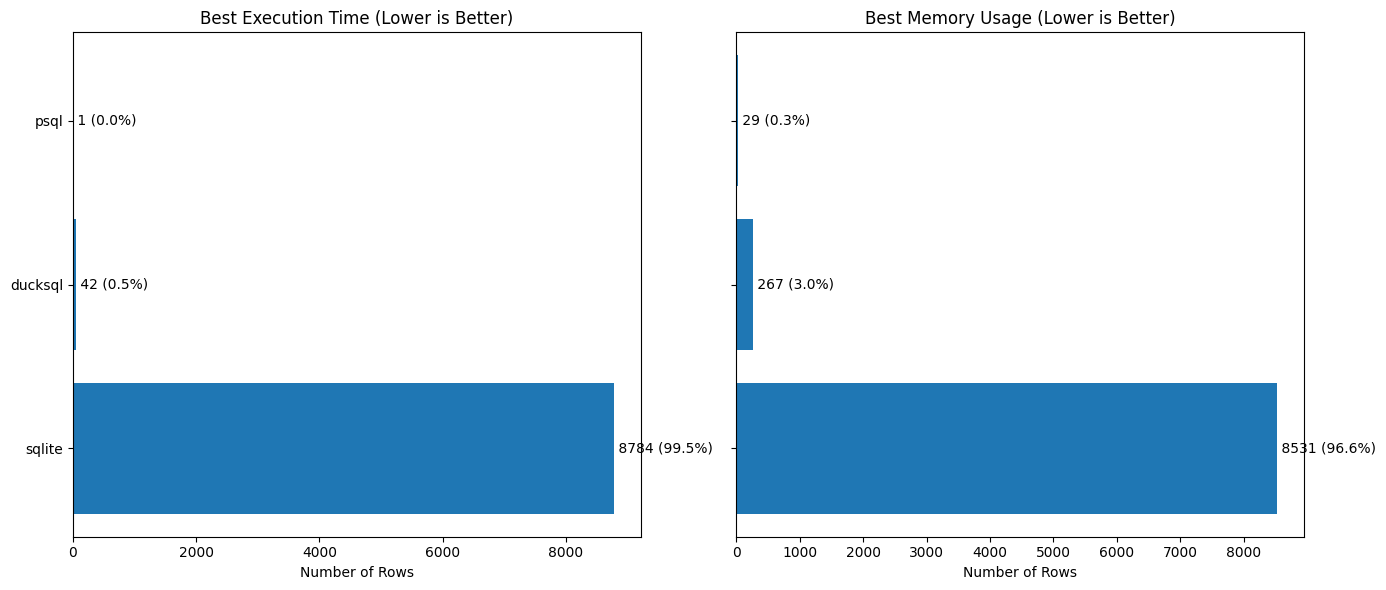

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

METHODS = ["sqlite", "ducksql", "psql"]

# --------------------------------------------------
# BUILD COLUMN MAPS (cheap)
# --------------------------------------------------
time_cols = {
    m: [c for c in df.columns if c.endswith("time_s") and m in c]
    for m in METHODS
}
mem_cols = {
    m: [c for c in df.columns if c.endswith("mb") and m in c]
    for m in METHODS
}

# --------------------------------------------------
# VECTORIZED MIN PER METHOD
# --------------------------------------------------
time_min_df = pd.DataFrame({
    m: df[cols].min(axis=1)
    for m, cols in time_cols.items()
    if cols
})

mem_min_df = pd.DataFrame({
    m: df[cols].min(axis=1)
    for m, cols in mem_cols.items()
    if cols
})

# --------------------------------------------------
# BEST METHOD PER ROW (FAST)
# --------------------------------------------------
df["best_time_method"] = time_min_df.idxmin(axis=1)
df["best_mem_method"]  = mem_min_df.idxmin(axis=1)

# --------------------------------------------------
# COUNTS
# --------------------------------------------------
time_counts = (
    df["best_time_method"]
    .value_counts()
    .reindex(METHODS, fill_value=0)
)

mem_counts = (
    df["best_mem_method"]
    .value_counts()
    .reindex(METHODS, fill_value=0)
)

print("Best execution time counts:\n", time_counts)
print("\nBest memory usage counts:\n", mem_counts)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, counts, title in zip(
    axes,
    [time_counts, mem_counts],
    ["Best Execution Time", "Best Memory Usage"],
):
    ax.barh(counts.index, counts.values)
    ax.set_title(f"{title} (Lower is Better)")
    ax.set_xlabel("Number of Rows")

    total = counts.sum()
    for i, c in enumerate(counts.values):
        pct = 100 * c / total if total else 0
        ax.text(c, i, f" {c} ({pct:.1f}%)", va="center")

plt.tight_layout()
plt.show()


Rows before: 8819
Rows after:  8653
Rows dropped: 166
Best execution time counts:
 best_time_method
sqlite                  1115
ducksql                    0
psql                       0
density_matrix          3754
matrix_product_state    3442
extended_stabilizer      307
statevector_saved         35
Name: count, dtype: int64

Best memory usage counts:
 best_mem_method
sqlite                  3997
ducksql                    3
psql                       0
density_matrix          1944
matrix_product_state    1808
extended_stabilizer      774
statevector_saved        127
Name: count, dtype: int64


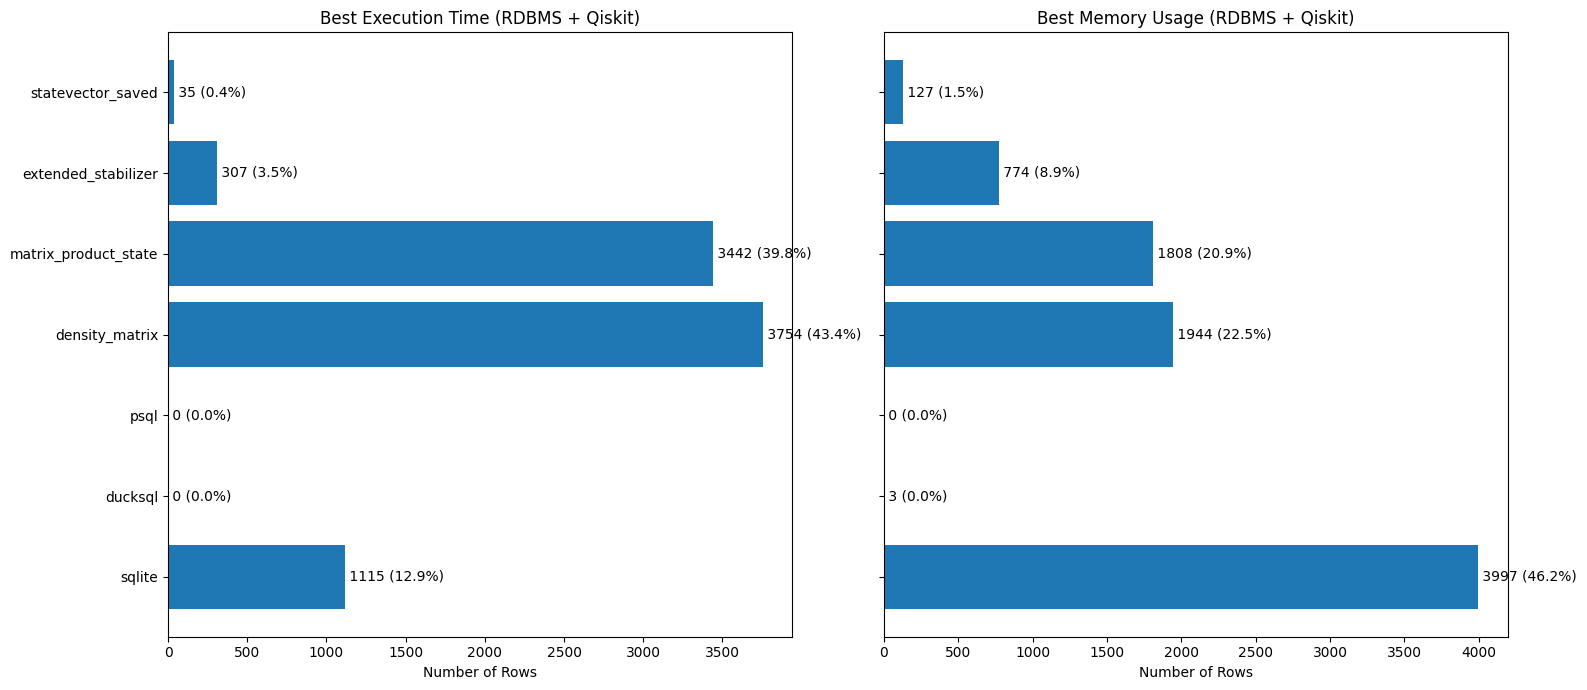

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Merge Qiskit
df_with_qiskit = df.merge(qiskit_df, on=PRIMARY_KEY, suffixes=("", "_qiskit"))

RDBMS_METHODS = METHODS
QISKIT_METHODS = [
    "density_matrix",
    "matrix_product_state",
    "extended_stabilizer",
    "statevector_saved",
]
ALL_METHODS = RDBMS_METHODS + QISKIT_METHODS

# --------------------------------------------------
# CLEAN QISKIT ROWS (already efficient)
# --------------------------------------------------
rows_before = len(df_with_qiskit)

qiskit_cols = [
    c for c in df_with_qiskit.columns
    if any(m in c for m in QISKIT_METHODS)
]

df_with_qiskit = df_with_qiskit.dropna(subset=qiskit_cols)

rows_after = len(df_with_qiskit)
print(f"Rows before: {rows_before}")
print(f"Rows after:  {rows_after}")
print(f"Rows dropped: {rows_before - rows_after}")

# --------------------------------------------------
# FAST BEST-METHOD COMPUTATION
# --------------------------------------------------

# Build column maps (cheap)
time_cols = {
    m: [c for c in df_with_qiskit.columns if m in c and c.endswith(("time_s", "execution_time"))]
    for m in ALL_METHODS
}
mem_cols = {
    m: [c for c in df_with_qiskit.columns if m in c and c.endswith(("mb", "memory_usage"))]
    for m in ALL_METHODS
}

# Vectorized min-per-method
time_min_df = pd.DataFrame({
    m: df_with_qiskit[cols].min(axis=1)
    for m, cols in time_cols.items()
    if cols
})

mem_min_df = pd.DataFrame({
    m: df_with_qiskit[cols].min(axis=1)
    for m, cols in mem_cols.items()
    if cols
})

# Best method per row (vectorized)
df_with_qiskit["best_time_method"] = time_min_df.idxmin(axis=1)
df_with_qiskit["best_mem_method"]  = mem_min_df.idxmin(axis=1)

# --------------------------------------------------
# COUNTS
# --------------------------------------------------
time_counts = (
    df_with_qiskit["best_time_method"]
    .value_counts()
    .reindex(ALL_METHODS, fill_value=0)
)

mem_counts = (
    df_with_qiskit["best_mem_method"]
    .value_counts()
    .reindex(ALL_METHODS, fill_value=0)
)

print("Best execution time counts:\n", time_counts)
print("\nBest memory usage counts:\n", mem_counts)

# --------------------------------------------------
# PLOT (already fast enough)
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, counts, title in zip(
    axes,
    [time_counts, mem_counts],
    ["Best Execution Time", "Best Memory Usage"],
):
    ax.barh(counts.index, counts.values)
    ax.set_title(f"{title} (RDBMS + Qiskit)")
    ax.set_xlabel("Number of Rows")

    total = counts.sum()
    for i, c in enumerate(counts.values):
        pct = 100 * c / total if total else 0
        ax.text(c, i, f" {c} ({pct:.1f}%)", va="center")

plt.tight_layout()
plt.show()


# Multiclass Qiskit and RDBMS methods

c:\Users\aadik\InferQ\analysis\venv\Lib\site-packages\xgboost\core.py:771: FutureWarning: Pass `objective` as keyword args.
  warnings.warn(msg, FutureWarning)


Random Forest        accuracy = 0.588
Decision Tree        accuracy = 0.552
Logistic Regression  accuracy = 0.298
Linear SVM           accuracy = 0.285
KNN                  accuracy = 0.581
XGBoost              accuracy = 0.514


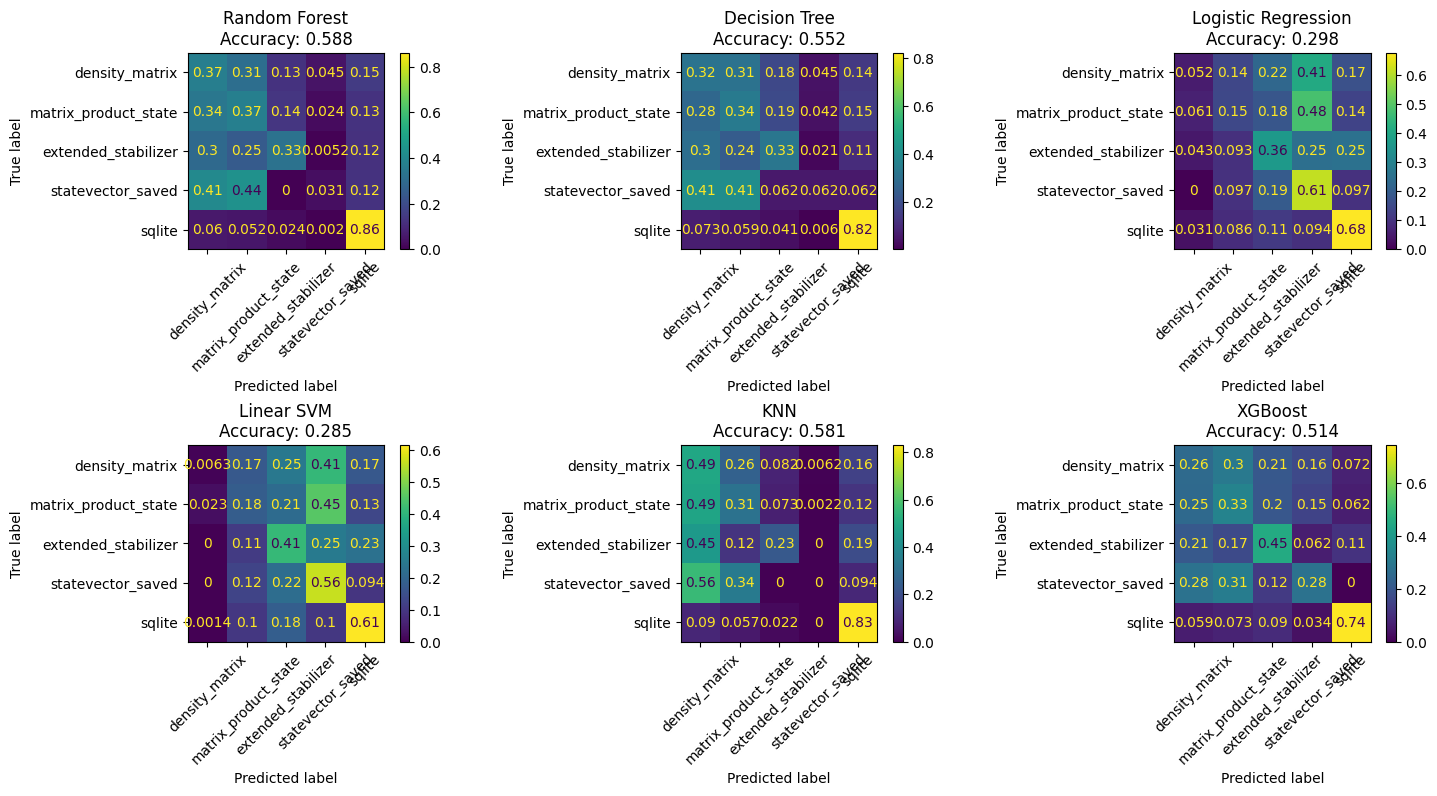

In [68]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from utils import PlotConfusionReports

ALL_METHODS = QISKIT_METHODS + ["sqlite"]

# --- data ---
X, y = df_with_qiskit[FEATURES], df_with_qiskit["best_mem_method"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# --- label encoding + class weights ---
le = LabelEncoder()
y_train_enc, y_test_enc = le.fit_transform(y_train), le.transform(y_test)
cw_enc = dict(zip(np.unique(y_train_enc), compute_class_weight("balanced", classes=np.unique(y_train_enc), y=y_train_enc)))
sw_xgb = np.array([cw_enc[c] for c in y_train_enc])

# --- models ---
models = {
    "Random Forest": RandomForestClassifier(300, class_weight="balanced", n_jobs=-1, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "Linear SVM": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="linear", class_weight="balanced"))]),
    "KNN": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier(7))]),
    "XGBoost": XGBClassifier(300, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
                             objective="multi:softmax", num_class=len(le.classes_), eval_metric="mlogloss", random_state=42)
}

# --- train / predict ---
preds = {}
for name, model in models.items():
    if name == "XGBoost":
        model.fit(X_train, y_train_enc, sample_weight=sw_xgb)
        y_pred = le.inverse_transform(model.predict(X_test))
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    preds[name] = y_pred
    print(f"{name:20s} accuracy = {accuracy_score(y_test, y_pred):.3f}")

# --- confusion plots ---
PlotConfusionReports(y_test, preds, ALL_METHODS)


# RDBMS vs Qiskit BINARY classification

Class distribution:
 family
qiskit    4653
rdbms     4000
Name: count, dtype: int64 

K-Nearest Neighbors  accuracy = 0.853
              precision    recall  f1-score   support

      qiskit      0.846     0.888     0.866       931
       rdbms      0.862     0.811     0.836       800

    accuracy                          0.853      1731
   macro avg      0.854     0.850     0.851      1731
weighted avg      0.853     0.853     0.852      1731

--------------------------------------------------
Logistic Regression  accuracy = 0.752
              precision    recall  f1-score   support

      qiskit      0.802     0.715     0.756       931
       rdbms      0.706     0.795     0.748       800

    accuracy                          0.752      1731
   macro avg      0.754     0.755     0.752      1731
weighted avg      0.758     0.752     0.752      1731

--------------------------------------------------
Linear SVM           accuracy = 0.754
              precision    recall  f1-score 

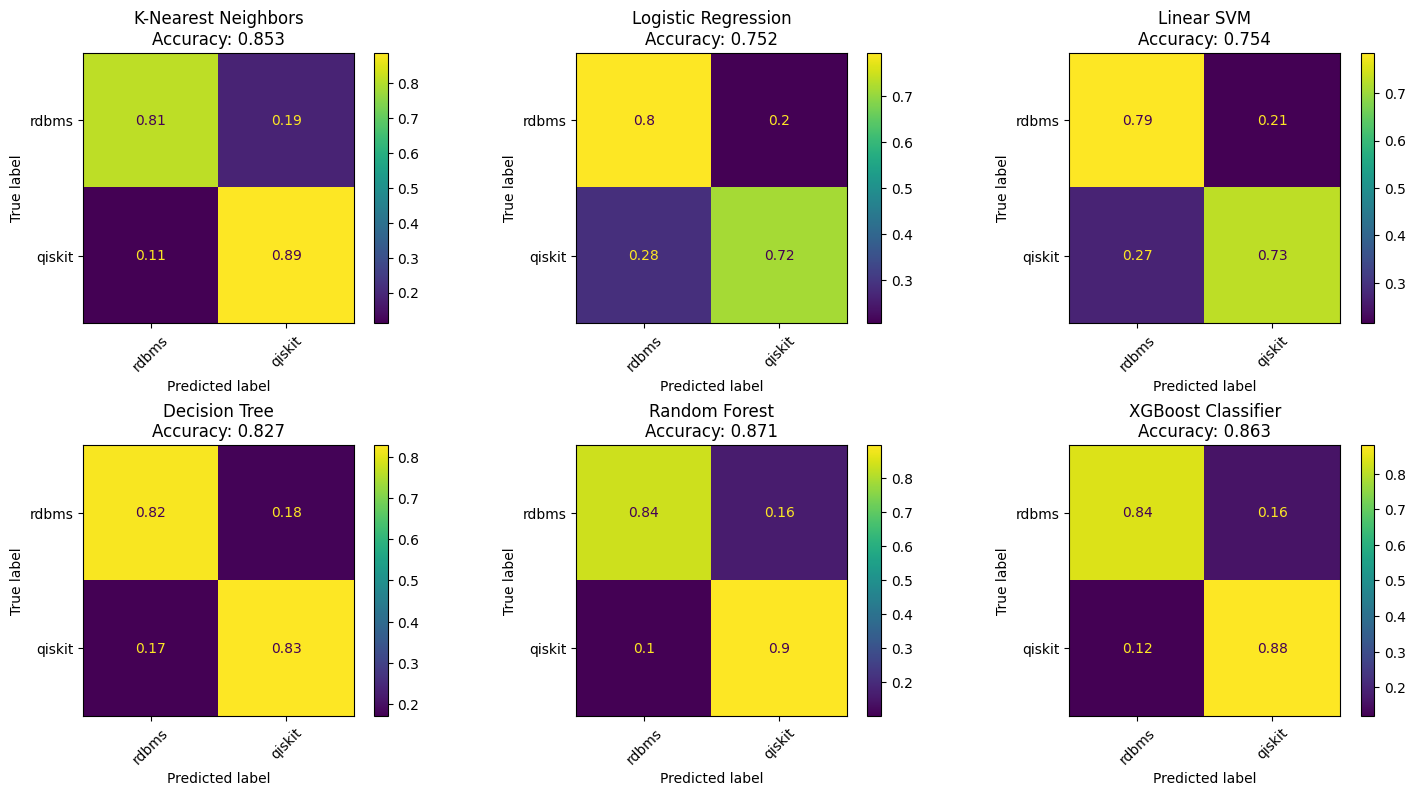

In [77]:
from sklearn.metrics import classification_report
# --- binary target ---
RDBMS_METHODS = {"psql", "ducksql", "sqlite", "infiniquantum"}
QISKIT_METHODS = {"statevector_saved", "density_matrix", "matrix_product_state", "extended_stabilizer", "statevector_saved"}

df_bin = df_with_qiskit.copy()
df_bin["family"] = df_bin["best_mem_method"].apply(
    lambda m: "rdbms" if m in RDBMS_METHODS else "qiskit" if m in QISKIT_METHODS else np.nan
)
df_bin = df_bin.dropna(subset=["family"])

X, y = df_bin[FEATURES], df_bin["family"]
print("Class distribution:\n", y.value_counts(), "\n")

# --- split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- encoding + weights ---
le = LabelEncoder()
y_train_enc, y_test_enc = le.fit_transform(y_train), le.transform(y_test)

cw = dict(zip(
    np.unique(y_train),
    compute_class_weight(class_weight="balanced",
                         classes=np.unique(y_train),
                         y=y_train)
))

cw_enc = dict(zip(
    np.unique(y_train_enc),
    compute_class_weight(class_weight="balanced",
                         classes=np.unique(y_train_enc),
                         y=y_train_enc)
))

sample_weights_xgb = np.array([cw_enc[c] for c in y_train_enc])

# --- models ---
models = {
    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(7))
    ]),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]),
    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="linear", class_weight="balanced"))
    ]),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(300, n_jobs=-1, class_weight="balanced", random_state=42),
    "XGBoost Classifier": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        objective="binary:logistic", eval_metric="logloss",
        random_state=42
    )
}

# --- train / evaluate ---
model_to_y_pred = {}

for name, model in models.items():
    if name == "XGBoost Classifier":
        model.fit(X_train, y_train_enc, sample_weight=sample_weights_xgb)
        y_pred = le.inverse_transform((model.predict(X_test) > 0.5).astype(int))
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    model_to_y_pred[name] = y_pred
    print(f"{name:20s} accuracy = {accuracy_score(y_test, y_pred):.3f}")
    print(classification_report(y_test, y_pred, digits=3))
    print("-" * 50)

# --- confusion matrices ---
PlotConfusionReports(y_test, model_to_y_pred, methods=["rdbms", "qiskit"])


# Analysing importance of SQL features for RDBMS profiling

In [81]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

models_to_compare = {
    "Linear SVM": models["Linear SVM"],
    # "Logistic Regression": models["Logistic Regression"],
    "Random Forest": models["Random Forest"],
    "XGBoost Classifier": models["XGBoost Classifier"],
}

# TOP_K = 10
# fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# for ax, (name, pipeline) in zip(axes, models_to_compare.items()):

#     clf = pipeline.named_steps["clf"]
#     coefs = clf.coef_.ravel()

#     importance_df = pd.DataFrame({
#         "feature": FEATURES,
#         "coefficient": coefs,
#         "abs_importance": np.abs(coefs)
#     }).sort_values("abs_importance", ascending=False)

#     print(f"\nTop 15 most important features ({name}):\n")
#     print(importance_df.head(15))

#     plot_df = importance_df.head(TOP_K).iloc[::-1]

#     ax.barh(plot_df["feature"], plot_df["coefficient"])
#     ax.axvline(0, linestyle="--", linewidth=1)
#     ax.set_title(f"{name} Feature Importance")
#     ax.set_xlabel("Coefficient Value")
#     ax.set_ylabel("Feature")

# fig.suptitle(
#     "Linear Model Feature Importance\n(Sign indicates RDBMS ↔ Qiskit decision)",
#     fontsize=14
# )

# plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.show()

# print("\nInterpretation:")
# print("• Positive coefficient  → pushes prediction toward class 'qiskit'")
# print("• Negative coefficient  → pushes prediction toward class 'rdbms'")
# print("• Larger magnitude      → stronger influence on decision")


Top 10 features (Linear SVM):
               feature  importance  abs_importance
4  num_select_columns   -0.217725        0.217725
0       num_agg_funcs   -1.597826        1.597826
1     num_and_clauses    1.975148        1.975148
2   num_eq_predicates   -2.721190        2.721190
5   num_where_clauses   -4.910235        4.910235
3           num_joins    6.604269        6.604269

Top 10 features (Random Forest):
               feature  importance  abs_importance
4  num_select_columns    0.149661        0.149661
1     num_and_clauses    0.159539        0.159539
0       num_agg_funcs    0.159827        0.159827
5   num_where_clauses    0.174138        0.174138
2   num_eq_predicates    0.176232        0.176232
3           num_joins    0.180602        0.180602

Top 10 features (XGBoost Classifier):
               feature  importance  abs_importance
4  num_select_columns    0.123065        0.123065
2   num_eq_predicates    0.128451        0.128451
1     num_and_clauses    0.130975        0.

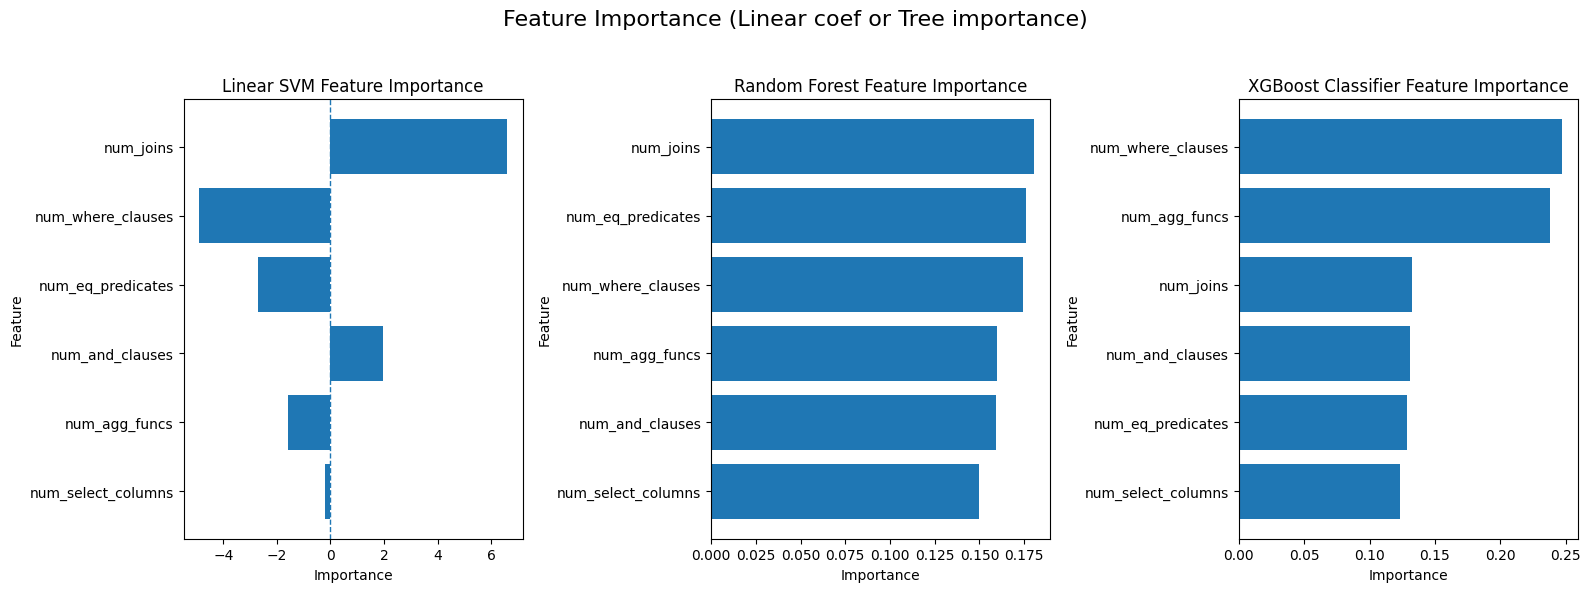

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TOP_K = 10
fig, axes = plt.subplots(1, len(models_to_compare), figsize=(16, 6))
axes = axes.ravel()

for ax, (name, model) in zip(axes, models_to_compare.items()):
    clf = model.named_steps["clf"] if hasattr(model, "named_steps") else model

    # Linear models: coefficients
    if hasattr(clf, "coef_"):
        imp = clf.coef_.ravel()
        feat_names = FEATURES
    # Tree models: feature_importances_
    elif hasattr(clf, "feature_importances_"):
        imp = clf.feature_importances_
        feat_names = FEATURES

    # Build DataFrame and select top K features
    df = pd.DataFrame({
        "feature": feat_names,
        "importance": imp,
        "abs_importance": np.abs(imp)
    }).sort_values("abs_importance", ascending=False).head(TOP_K).iloc[::-1]

    ax.barh(df["feature"], df["importance"])  # default color
    if hasattr(clf, "coef_"):
        ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_title(f"{name} Feature Importance")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")

    print(f"\nTop {TOP_K} features ({name}):\n", df)

fig.suptitle("Feature Importance (Linear coef or Tree importance)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [83]:
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(2, 1, figsize=(9, 10))

# # Histogram: num_and_clauses
# axes[0].hist(df_bin.loc[df_bin.family == "rdbms",  "num_and_clauses"],
#              bins=10, density=True, alpha=0.6, label="RDBMS")
# axes[0].hist(df_bin.loc[df_bin.family == "qiskit", "num_and_clauses"],
#              bins=10, density=True, alpha=0.6, label="Qiskit")
# axes[0].set_xlabel("num_and_clauses")
# axes[0].set_ylabel("Density")
# axes[0].set_title("num_and_clauses by execution family")
# axes[0].legend()

# # Scatter: num_joins vs num_agg_funcs
# axes[1].scatter(df_bin.loc[df_bin.family == "rdbms", "num_joins"],
#                 df_bin.loc[df_bin.family == "rdbms", "num_agg_funcs"],
#                 alpha=0.6, label="RDBMS")
# axes[1].scatter(df_bin.loc[df_bin.family == "qiskit", "num_joins"],
#                 df_bin.loc[df_bin.family == "qiskit", "num_agg_funcs"],
#                 alpha=0.6, label="Qiskit")
# axes[1].set_xlabel("num_joins")
# axes[1].set_ylabel("num_agg_funcs")
# axes[1].set_title("num_joins vs num_agg_funcs")
# axes[1].legend()

# plt.tight_layout()
# plt.show()
